In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Hyperparameters
batch_size = 128
learning_rate = 0.001
epochs = 10
latent_dim = 20

#### Hyperparameters are predefined parameters that control the training process of a model and must be set before training.
#### batch size = Improves training speed and memory efficiency.
#### learning rate = Improves training speed and memory efficiency.
#### epochs = Allows the model to learn patterns from the dataset multiple times.
#### latent dimention = Controls how much information is stored in the compressed representation.

In [4]:
#  LOAD MNIST DATASET

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)



100%|██████████| 9.91M/9.91M [00:00<00:00, 37.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.32MB/s]


#### Here we import the dataset

In [5]:
#  DEFINE VAE MODEL

class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 28*28)

    # Encoder
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    # Reparameterization Trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    # Decoder
    def decode(self, z):
        h = torch.relu(self.fc2(z))
        x_reconstructed = torch.sigmoid(self.fc3(h))
        return x_reconstructed

    # Forward pass
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)


#### Encoder : The encoder converts the input image into a compressed latent representation.
#### Instead of producing a single vector, a VAE encoder outputs two values:
> μ (mean)

>log σ² (log variance)

#### Decoder : The decoder reconstructs the original image from the latent vector z.
#### It tries to recreate the input image from the compressed representation.

#### Forward Pass : The forward pass defines how data flows through the entire neural network.
#### It specifies the sequence of operations performed when an input is given to the model.


In [6]:
# LOSS FUNCTION

def vae_loss(reconstructed, original, mu, logvar):

    # Reconstruction Loss
    recon_loss = nn.functional.binary_cross_entropy(
        reconstructed,
        original,
        reduction='sum'
    )

    # KL Divergence Loss
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss


#### Reconstruction loss measures how similar the reconstructed image is to the original input image.

#### KL Divergence forces the latent space distribution to be close to a standard normal distribution.

In [7]:
# TRAINING LOOP

for epoch in range(epochs):

    total_loss = 0

    for data, _ in train_loader:

        data = data.view(-1, 28*28).to(device)

        optimizer.zero_grad()

        reconstructed, mu, logvar = model(data)

        loss, recon_loss, kl_loss = vae_loss(
            reconstructed,
            data,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Total Loss: {total_loss/len(train_loader.dataset):.4f}")
    print(f"Reconstruction Loss: {recon_loss.item():.4f}")
    print(f"KL Divergence Loss: {kl_loss.item():.4f}")



Epoch [1/10]
Total Loss: 163.5837
Reconstruction Loss: 10692.9551
KL Divergence Loss: 1852.7731
Epoch [2/10]
Total Loss: 121.1366
Reconstruction Loss: 8792.5830
KL Divergence Loss: 2156.9663
Epoch [3/10]
Total Loss: 114.1561
Reconstruction Loss: 8355.4668
KL Divergence Loss: 2333.7927
Epoch [4/10]
Total Loss: 111.3022
Reconstruction Loss: 8393.8965
KL Divergence Loss: 2387.9998
Epoch [5/10]
Total Loss: 109.6821
Reconstruction Loss: 8050.1816
KL Divergence Loss: 2390.7969
Epoch [6/10]
Total Loss: 108.4915
Reconstruction Loss: 7344.7749
KL Divergence Loss: 2321.4502
Epoch [7/10]
Total Loss: 107.7079
Reconstruction Loss: 8197.1348
KL Divergence Loss: 2443.2290
Epoch [8/10]
Total Loss: 107.0005
Reconstruction Loss: 7934.2891
KL Divergence Loss: 2421.9353
Epoch [9/10]
Total Loss: 106.5123
Reconstruction Loss: 7652.6289
KL Divergence Loss: 2391.4243
Epoch [10/10]
Total Loss: 106.0874
Reconstruction Loss: 7741.6743
KL Divergence Loss: 2442.5857


#### Total loss decreases across epochs, showing the model is learning.

#### Reconstruction loss decreases, meaning the model reconstructs MNIST images better.

#### KL divergence regularizes the latent space to follow a normal distribution.

#### Overall, the VAE learns meaningful latent representations and reconstructs images effectively.

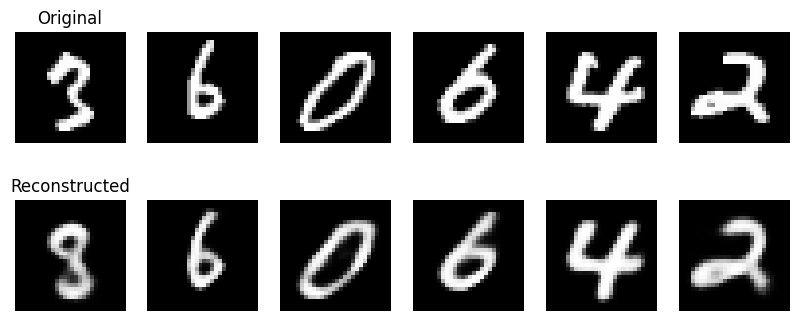

In [8]:
# VISUALIZE RECONSTRUCTION

def show_reconstruction(model, data_loader):

    model.eval()

    with torch.no_grad():

        data, _ = next(iter(data_loader))

        data = data.view(-1, 28*28).to(device)

        reconstructed, _, _ = model(data)

        original = data.view(-1,1,28,28).cpu()
        reconstructed = reconstructed.view(-1,1,28,28).cpu()

        fig, axes = plt.subplots(2,6, figsize=(10,4))

        for i in range(6):

            axes[0,i].imshow(original[i][0], cmap='gray')
            axes[0,i].axis('off')

            axes[1,i].imshow(reconstructed[i][0], cmap='gray')
            axes[1,i].axis('off')

        axes[0,0].set_title("Original")
        axes[1,0].set_title("Reconstructed")

        plt.show()


show_reconstruction(model, train_loader)